# Network Centrality — Example Graphs

This notebook demonstrates the main centrality measures on small example graphs:

| Measure | Intuition |
|---|---|
| **Degree** | How many connections a node has |
| **Closeness** | How close a node is to all others (inverse avg. shortest path) |
| **Betweenness** | How often a node lies on shortest paths between others |
| **Eigenvector** | Being connected to other well-connected nodes |
| **PageRank** | Random-surfer importance (damped eigenvector variant) |
| **Katz** | Weighted count of all paths from every node (with attenuation) |

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

In [2]:
def draw_centrality(G, centrality, title, pos=None, ax=None, cmap='coolwarm'):
    """Draw a graph with nodes coloured and sized by a centrality dict."""
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    vals = np.array([centrality[n] for n in G.nodes()])
    norm = Normalize(vmin=vals.min(), vmax=vals.max())
    colours = cm.get_cmap(cmap)(norm(vals))
    sizes = 300 + 2000 * norm(vals)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colours, node_size=sizes, edgecolors='k', linewidths=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    # plt.colorbar(sm, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    return pos

## 1. A Small Example Graph (Krackhardt Kite)

The Krackhardt kite is a classic 10-node graph that nicely separates different centrality concepts: the most *connected* node is not necessarily the most *between* or *close*.

/tmp/ipykernel_31230/3619087230.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap(cmap)(norm(vals))


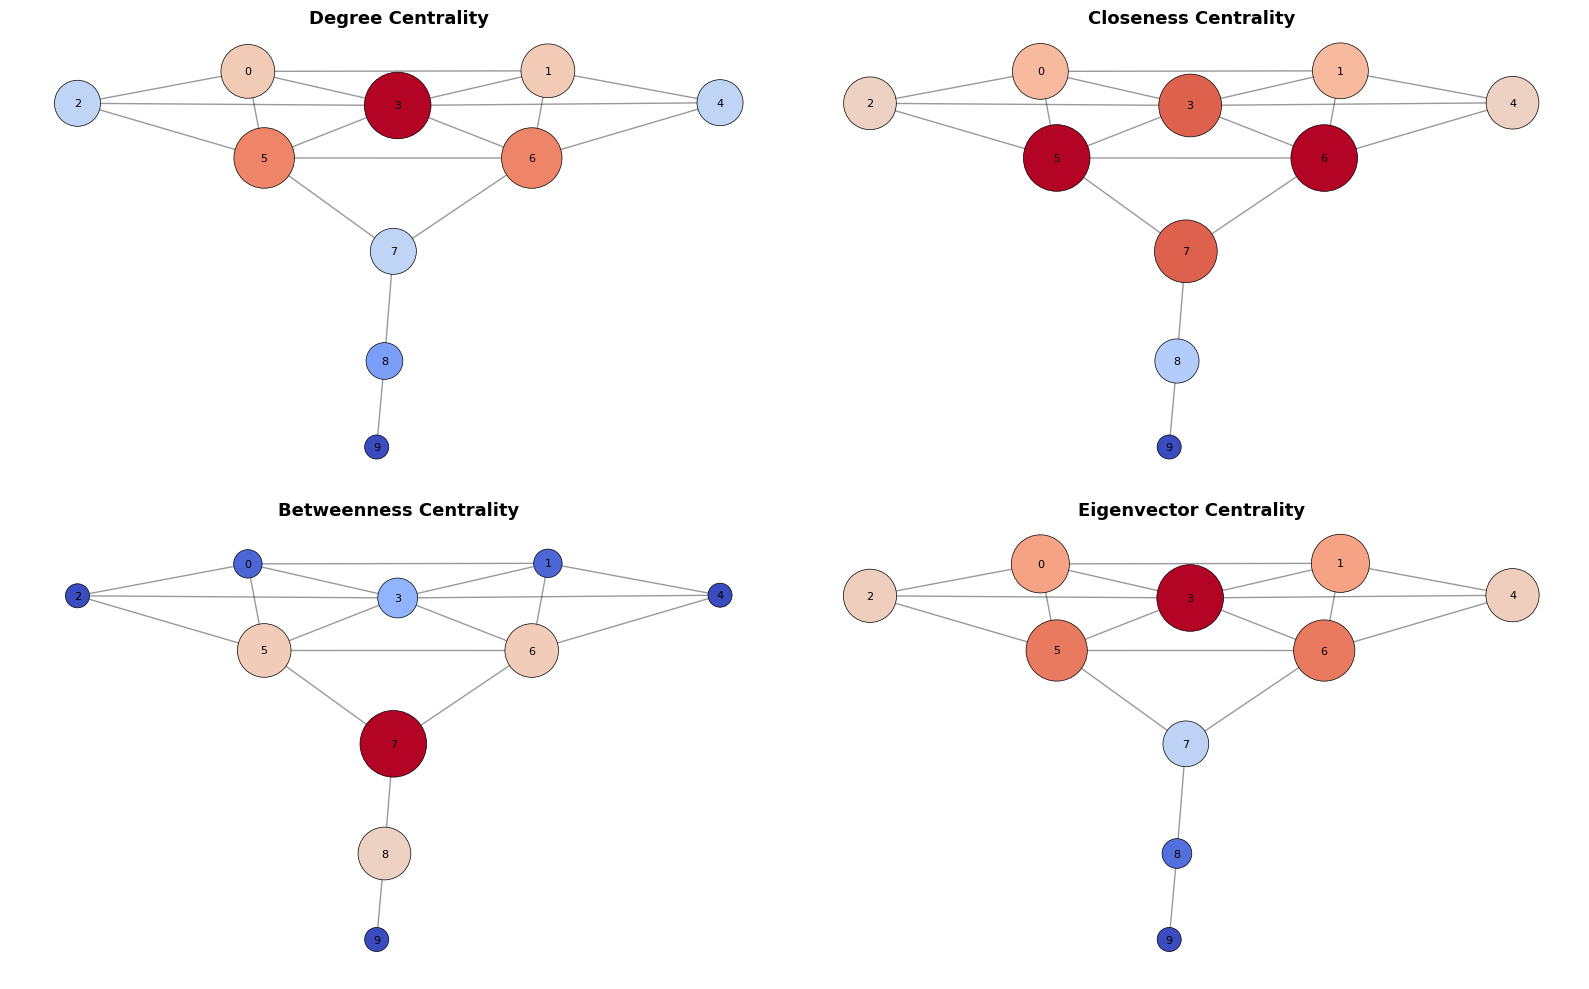

In [3]:
G_kite = nx.krackhardt_kite_graph()
pos_kite = nx.spring_layout(G_kite, seed=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
centralities = [
    (nx.degree_centrality(G_kite),      'Degree Centrality'),
    (nx.closeness_centrality(G_kite),   'Closeness Centrality'),
    (nx.betweenness_centrality(G_kite), 'Betweenness Centrality'),
    (nx.eigenvector_centrality(G_kite), 'Eigenvector Centrality'),
    # (nx.pagerank(G_kite),               'PageRank'),
    # (nx.katz_centrality(G_kite),        'Katz Centrality'),
]
for ax, (cent, title) in zip(axes.flat, centralities):
    draw_centrality(G_kite, cent, title, pos=pos_kite, ax=ax)

# fig.suptitle('Krackhardt Kite Graph — Six Centrality Measures', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./example_kite_centralities.png', dpi=300,transparent = True, bbox_inches='tight')

In [4]:
# Summary table
import pandas as pd

rows = []
for cent, name in centralities:
    top_node = max(cent, key=cent.get)
    rows.append({'Measure': name, 'Top Node': top_node, 'Score': f"{cent[top_node]:.4f}"})
pd.DataFrame(rows)

,Measure,Top Node,Score
0,Degree Centrality,3,0.6667
1,Closeness Centrality,5,0.6429
2,Betweenness Centrality,7,0.3889
3,Eigenvector Centrality,3,0.4810


## 2. Karate Club Graph (Zachary, 1977)

A classic social-network benchmark: 34 members of a university karate club, with edges representing friendships observed outside the club.

/tmp/ipykernel_31230/3619087230.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap(cmap)(norm(vals))


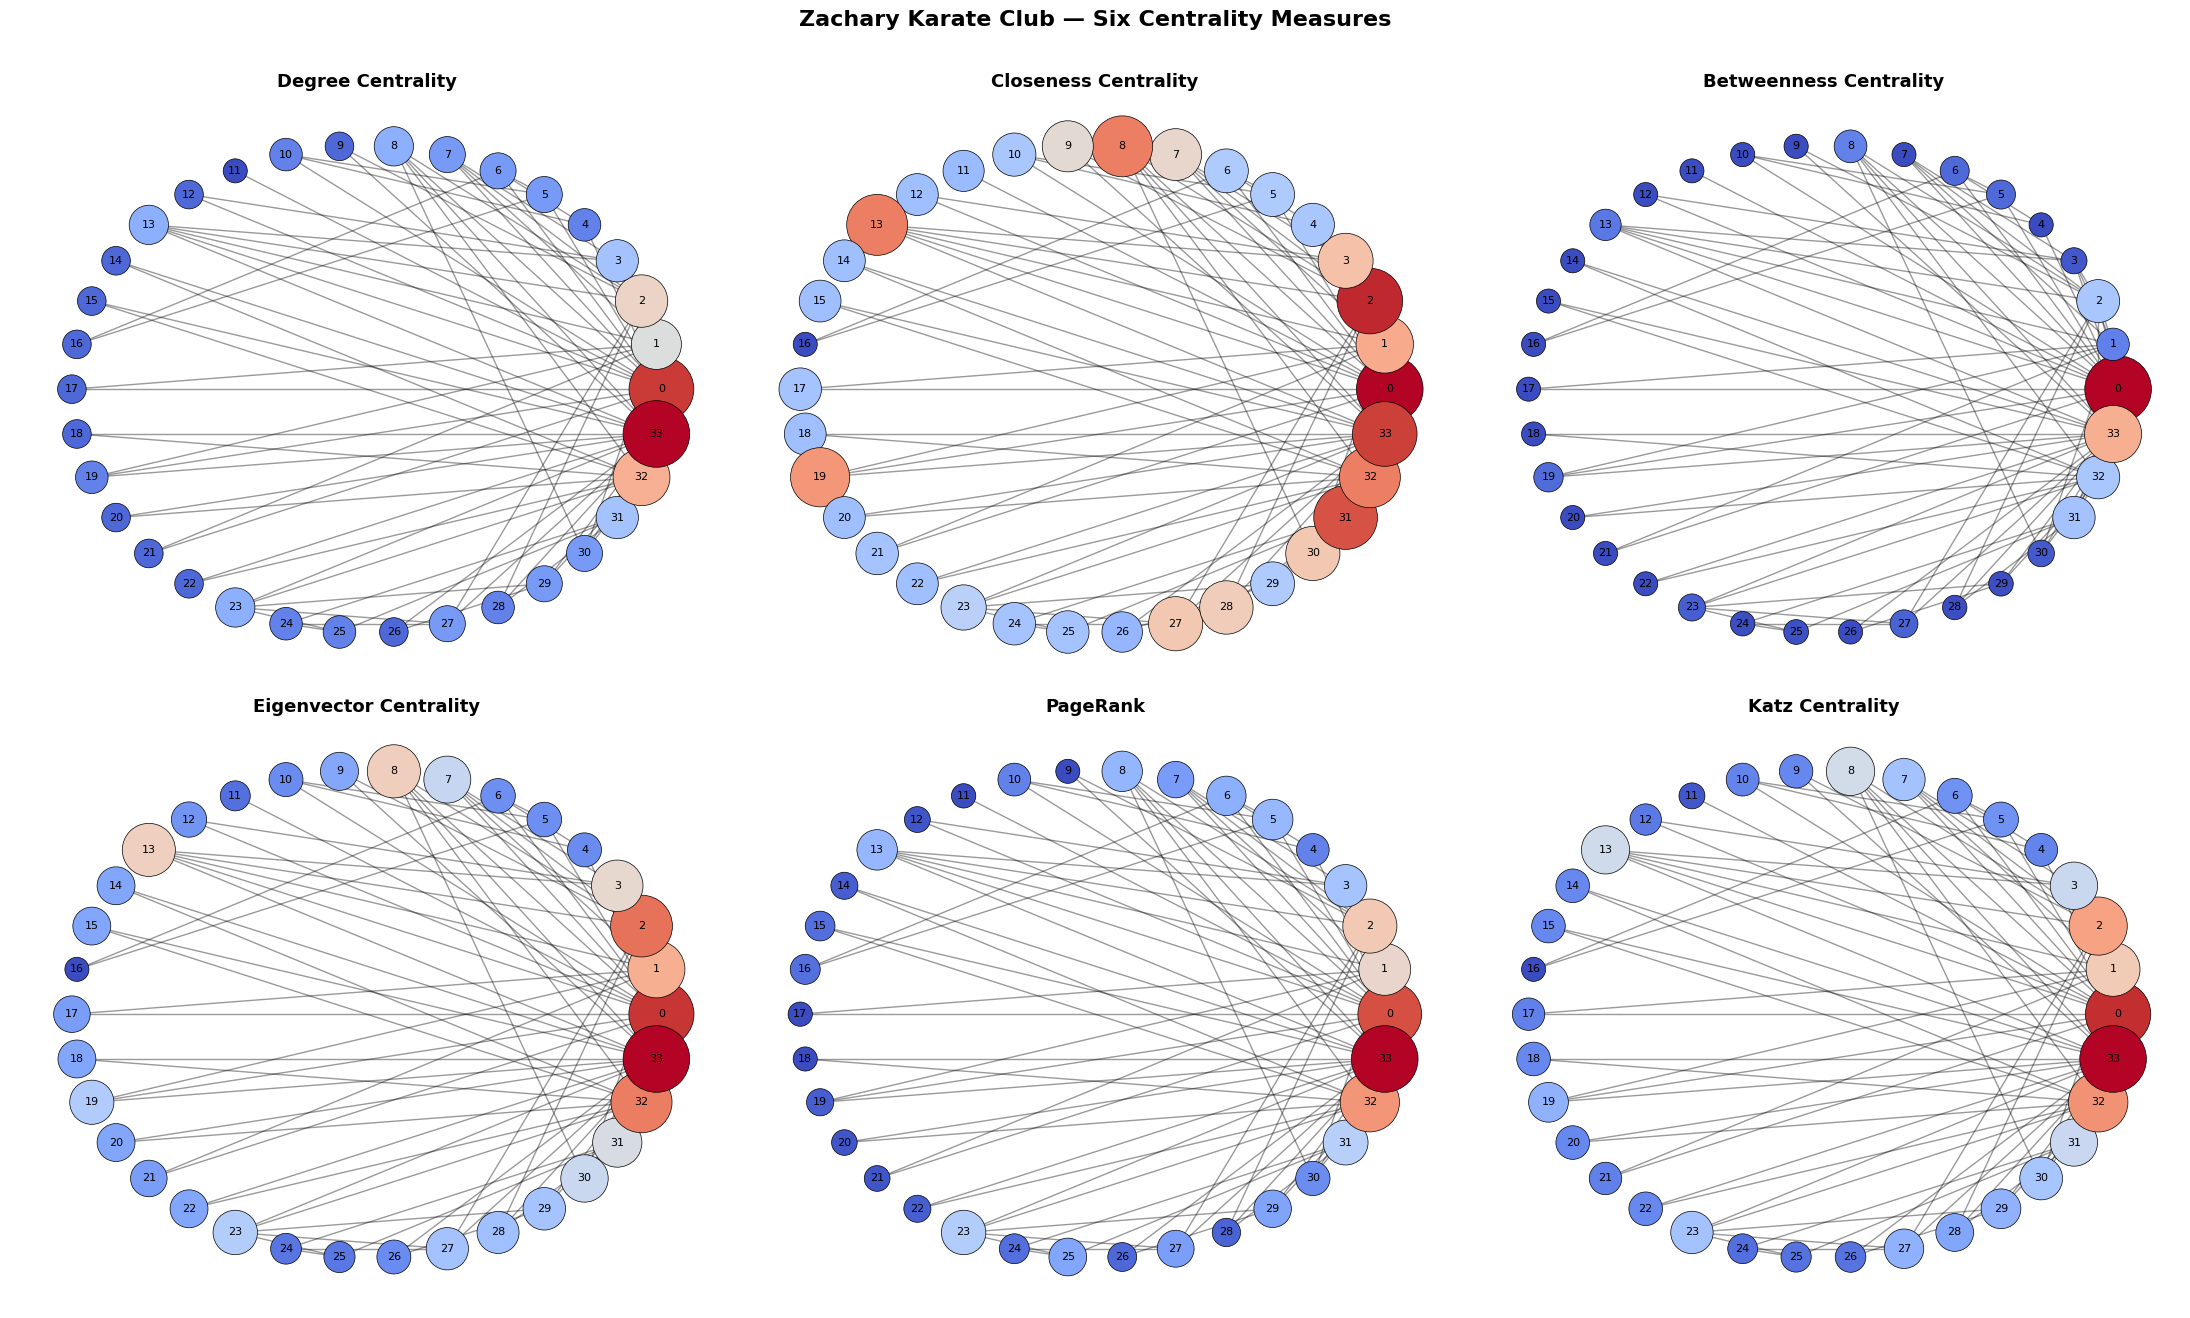

In [5]:
G_karate = nx.karate_club_graph()
pos_karate = nx.circular_layout(G_karate)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
centralities_k = [
    (nx.degree_centrality(G_karate),      'Degree Centrality'),
    (nx.closeness_centrality(G_karate),   'Closeness Centrality'),
    (nx.betweenness_centrality(G_karate), 'Betweenness Centrality'),
    (nx.eigenvector_centrality(G_karate), 'Eigenvector Centrality'),
    (nx.pagerank(G_karate),               'PageRank'),
    (nx.katz_centrality(G_karate),        'Katz Centrality'),
]
for ax, (cent, title) in zip(axes.flat, centralities_k):
    draw_centrality(G_karate, cent, title, pos=pos_karate, ax=ax)

fig.suptitle('Zachary Karate Club — Six Centrality Measures', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. In-Degree vs Out-Degree on a Small Directed Graph

A minimal 4-node directed graph that clearly separates **in-degree** (who receives edges) from **out-degree** (who sends edges).

/tmp/ipykernel_31230/1885571197.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(0.2+norm(vals))
/tmp/ipykernel_31230/1885571197.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(0.2+norm(vals))


Node | In-Degree | Out-Degree
-----|-----------|----------
  1  |   0.3333  |   0.3333
  2  |   0.3333  |   0.3333
  3  |   1.0000  |   0.3333
  4  |   0.0000  |   0.6667


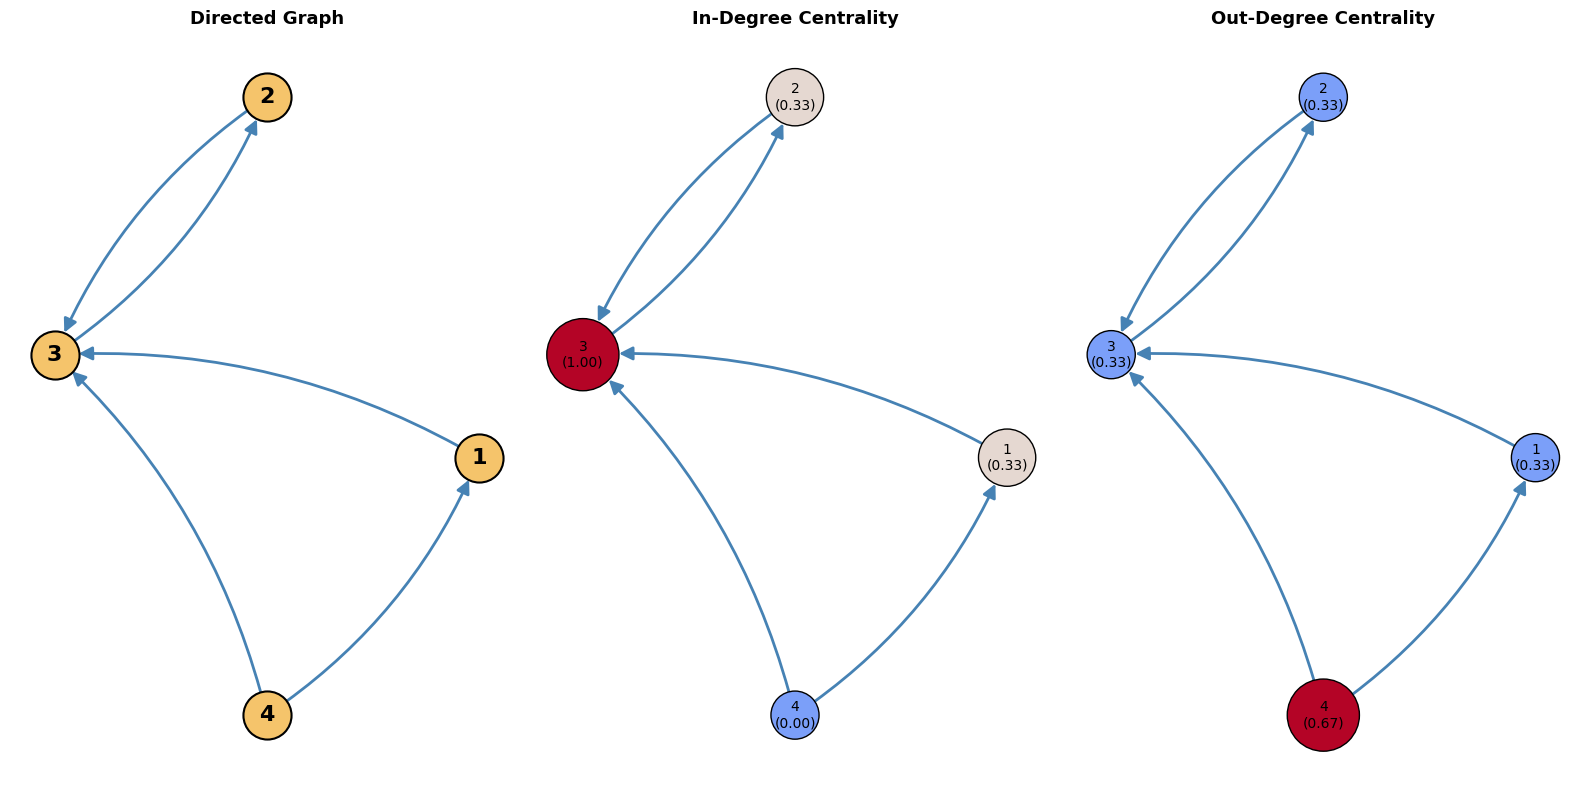

In [6]:
# Graph from the diagram: nodes 1-4
# Edges: 2↔3 (bidirectional), 1→3, 4→3, 4→1
G_small = nx.DiGraph()
G_small.add_edges_from([(2, 3), (3, 2), (1, 3), (4, 3), (4, 1)])

# Position nodes to match the diagram layout
pos_small = {
    1: (1.0, 0.3),   # right
    2: (0.5, 1.0),   # top
    3: (0.0, 0.5),   # left
    4: (0.5, -0.2),  # bottom
}

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# --- Panel 1: The graph itself ---
ax = axes[0]
nx.draw_networkx_edges(G_small, pos_small, ax=ax, arrows=True, arrowsize=20,node_size=1200,
                       connectionstyle='arc3,rad=0.15', edge_color='steelblue', width=2)
nx.draw_networkx_nodes(G_small, pos_small, ax=ax, node_size=1200,
                       node_color='#f5c46b', edgecolors='k', linewidths=1.5)
nx.draw_networkx_labels(G_small, pos_small, ax=ax, font_size=16, font_weight='bold')
ax.set_title('Directed Graph', fontsize=13, fontweight='bold')
ax.axis('off')

# --- Panel 2: In-degree centrality ---
ax = axes[1]
in_deg = nx.in_degree_centrality(G_small)
vals = np.array([in_deg[n] for n in G_small.nodes()])
norm = Normalize(vmin=vals.min(), vmax=vals.max())
colours = cm.get_cmap('coolwarm')(0.2+norm(vals))
sizes = 1200 + 1500 * norm(vals)
nx.draw_networkx_edges(G_small, pos_small, ax=ax, arrows=True, arrowsize=20,node_size=sizes,
                       connectionstyle='arc3,rad=0.15', edge_color='steelblue', width=2)
nx.draw_networkx_nodes(G_small, pos_small, ax=ax, node_color=colours,
                       node_size=sizes, edgecolors='k', linewidths=1)
labels_in = {n: f'{n}\n({in_deg[n]:.2f})' for n in G_small.nodes()}
nx.draw_networkx_labels(G_small, pos_small, labels=labels_in, ax=ax, font_size=10)
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm); sm.set_array([])
# plt.colorbar(sm, ax=ax, shrink=0.7)
ax.set_title('In-Degree Centrality', fontsize=13, fontweight='bold')
ax.axis('off')

# --- Panel 3: Out-degree centrality ---
ax = axes[2]
out_deg = nx.out_degree_centrality(G_small)
vals = np.array([out_deg[n] for n in G_small.nodes()])
norm = Normalize(vmin=vals.min(), vmax=vals.max())
colours = cm.get_cmap('coolwarm')(0.2+norm(vals))
sizes = 1200 + 1500 * norm(vals)
nx.draw_networkx_edges(G_small, pos_small, ax=ax, arrows=True, arrowsize=20,node_size=sizes,
                       connectionstyle='arc3,rad=0.15', edge_color='steelblue', width=2)
nx.draw_networkx_nodes(G_small, pos_small, ax=ax, node_color=colours,
                       node_size=sizes, edgecolors='k', linewidths=1)
labels_out = {n: f'{n}\n({out_deg[n]:.2f})' for n in G_small.nodes()}
nx.draw_networkx_labels(G_small, pos_small, labels=labels_out, ax=ax, font_size=10)
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm); sm.set_array([])
# plt.colorbar(sm, ax=ax, shrink=0.7)
ax.set_title('Out-Degree Centrality', fontsize=13, fontweight='bold')
ax.axis('off')

# fig.suptitle('In-Degree vs Out-Degree: Node 3 receives the most, Node 4 sends the most',
#              fontsize=12, style='italic', y=0.01)
plt.tight_layout()
plt.savefig('./in_out_degree_centrality.png', dpi = 300, transparent = True, bbox_inches = 'tight')

# Summary
print("Node | In-Degree | Out-Degree")
print("-----|-----------|----------")
for n in sorted(G_small.nodes()):
    print(f"  {n}  |   {in_deg[n]:.4f}  |   {out_deg[n]:.4f}")

## 4. Directed Graph — Centrality on a Larger Structure

For directed graphs, **in-degree** and **out-degree** centrality differ, and PageRank is particularly natural.

/tmp/ipykernel_31230/4155035947.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(norm(vals))


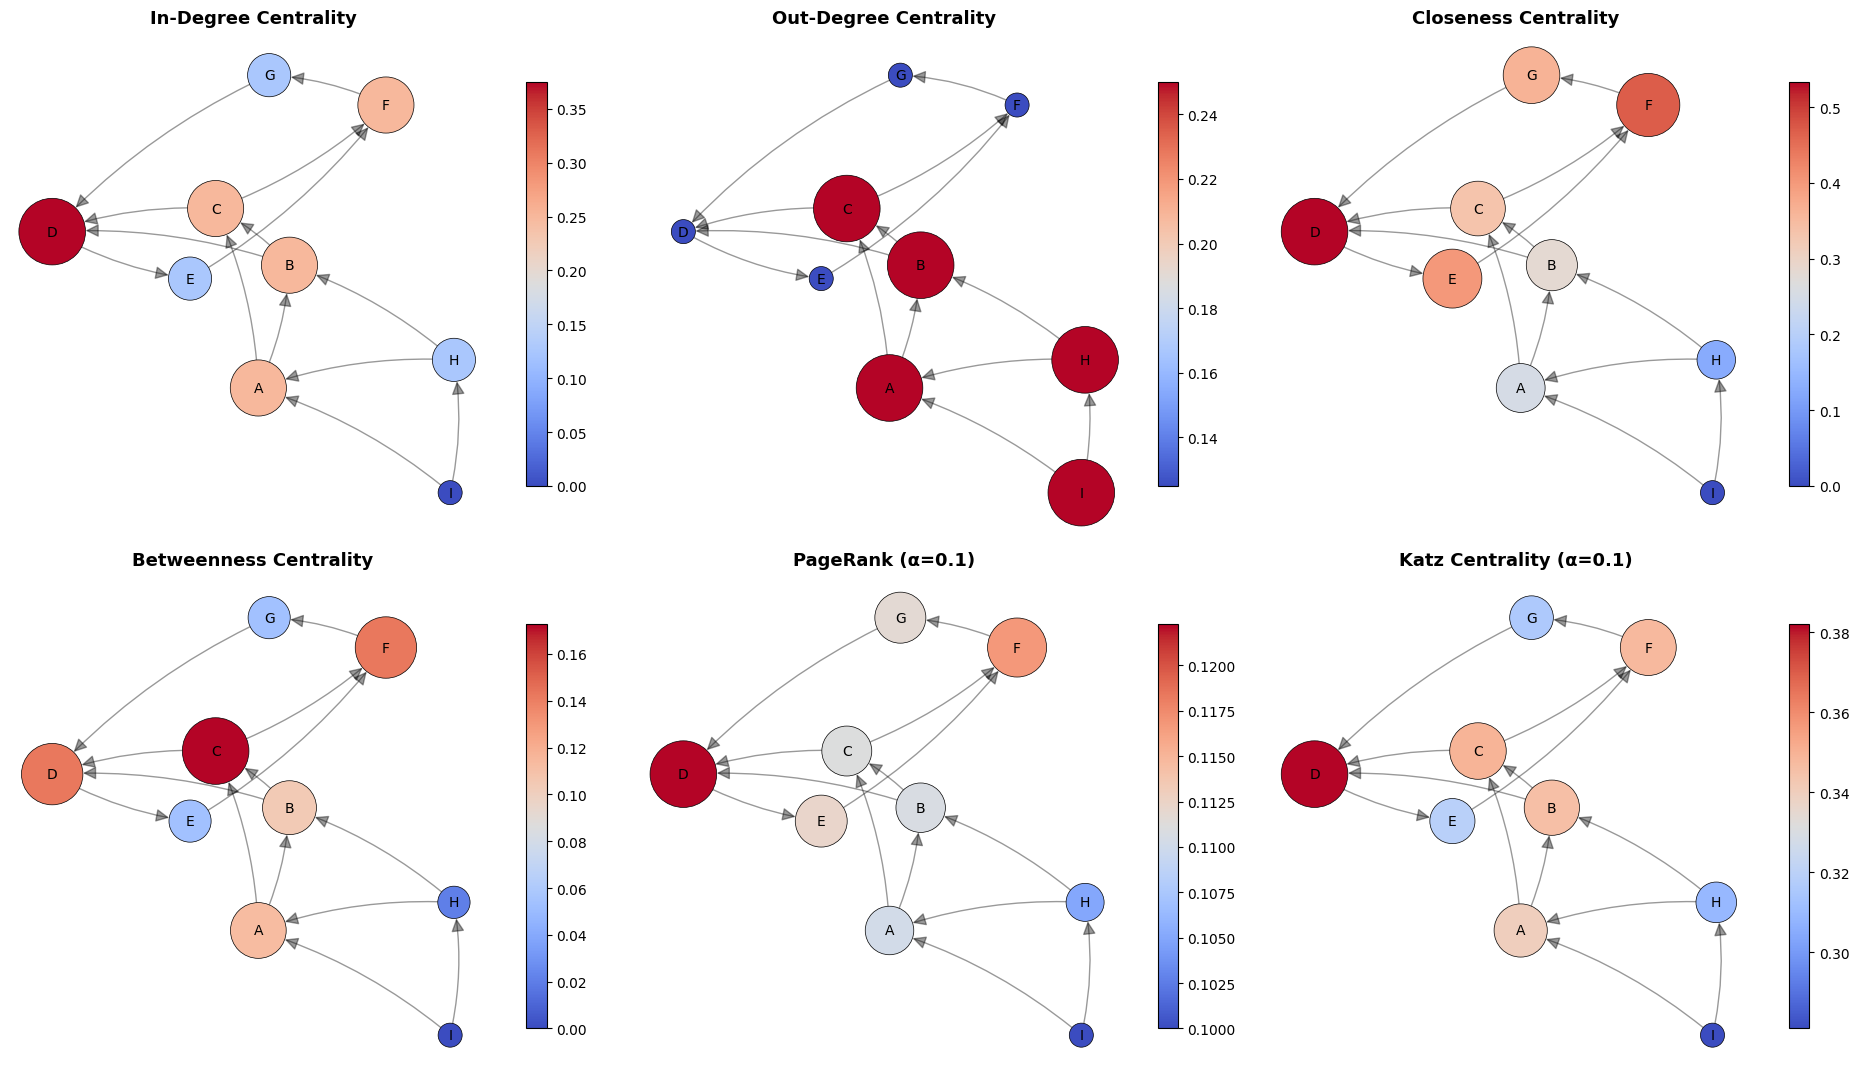

In [7]:
# Build a small directed graph
G_dir = nx.DiGraph()
edges = [
    ('A','B'), ('A','C'), ('B','C'), ('B','D'), ('C','D'),
    ('D','E'), ('E','F'), ('F','G'), ('G','D'), ('C','F'),
    ('H','A'), ('H','B'), ('I','H'), ('I','A'),
]
G_dir.add_edges_from(edges)
pos_dir = nx.spring_layout(G_dir, seed=21)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
centralities_dir = [
    (nx.in_degree_centrality(G_dir),           'In-Degree Centrality'),
    (nx.out_degree_centrality(G_dir),          'Out-Degree Centrality'),
    (nx.closeness_centrality(G_dir),           'Closeness Centrality'),
    (nx.betweenness_centrality(G_dir),         'Betweenness Centrality'),
    (nx.pagerank(G_dir, alpha= 0.1),                       'PageRank (α=0.1)'),
    (nx.katz_centrality(G_dir, alpha=0.1),     'Katz Centrality (α=0.1)'),
]
for ax, (cent, title) in zip(axes.flat, centralities_dir):
    vals = np.array([cent[n] for n in G_dir.nodes()])
    norm = Normalize(vmin=vals.min(), vmax=vals.max())
    colours = cm.get_cmap('coolwarm')(norm(vals))
    sizes = 300 + 2000 * norm(vals)
    nx.draw_networkx_edges(G_dir, pos_dir, ax=ax, alpha=0.4, arrows=True,node_size=sizes,
                           arrowsize=20, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G_dir, pos_dir, ax=ax, node_color=colours,
                           node_size=sizes, edgecolors='k', linewidths=0.5)
    nx.draw_networkx_labels(G_dir, pos_dir, ax=ax, font_size=10)
    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

# fig.suptitle('Directed Graph — Six Centrality Measures', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('directed_graph_centralities.png', dpi=300, transparent = True, bbox_inches='tight')

## 6. Centrality Correlation Heatmap

How correlated are the different centrality measures on the Karate Club graph?

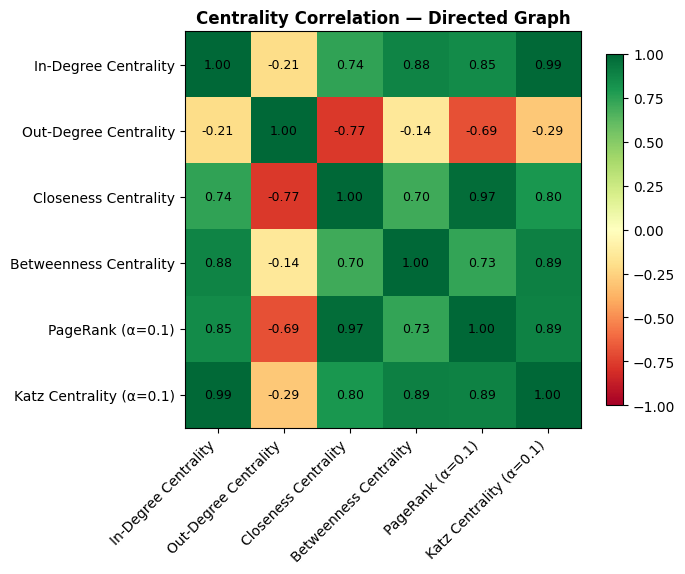

In [8]:
import pandas as pd

df_cent = pd.DataFrame({name: cent for cent, name in centralities_dir})
corr = df_cent.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Centrality Correlation — Directed Graph', fontweight='bold')
plt.tight_layout()
plt.savefig('centrality_correlation_directed.png', dpi=300, transparent = True, bbox_inches='tight')

## 7. Graph Centralization

**Node centrality** measures how important a single node is. **Graph centralization** measures how unequal the centrality distribution is across the whole network — i.e. how much the graph revolves around a single node.

Freeman's general centralization formula:

$$C_X = \frac{\sum_{i=1}^{n} \bigl[C_X(v^*) - C_X(v_i)\bigr]}{\max \sum_{i=1}^{n} \bigl[C_X(v^*) - C_X(v_i)\bigr]}$$

where $C_X(v^*)$ is the maximum centrality in the graph. The denominator is the theoretical maximum (achieved by a **star graph**).

| Value | Interpretation |
|---|---|
| 0 | All nodes equally central (e.g. complete graph, cycle) |
| 1 | Maximally centralised (star graph) |

We compute degree, closeness, and betweenness centralization for several example graphs.

In [9]:
def graph_centralization(G, centrality_func):
    """
    Compute Freeman's graph centralization for an undirected graph.
    
    C = sum(c_max - c_i) / max_possible_sum
    
    The theoretical maximum denominator depends on the measure:
    - Degree:      (n-1)(n-2)  / (n-1)  => simplified via star graph
    - Closeness:   (n-1)(n-2) / (2n-3)
    - Betweenness: (n-1)(n-2) / 2
    
    We compute it empirically using a star graph of the same size.
    """
    cent = centrality_func(G)
    c_max = max(cent.values())
    n = G.number_of_nodes()
    
    numerator = sum(c_max - c for c in cent.values())
    
    # Theoretical max: star graph of same order
    S = nx.star_graph(n - 1)  # n nodes: 1 hub + (n-1) spokes
    cent_star = centrality_func(S)
    c_star_max = max(cent_star.values())
    denominator = sum(c_star_max - c for c in cent_star.values())
    
    if denominator == 0:
        return 0.0
    return numerator / denominator

In [10]:
# Build a collection of example graphs with different structures
example_graphs = {
    'Star (n=10)':       nx.star_graph(9),
    'Complete (n=10)':   nx.complete_graph(10),
    'Cycle (n=10)':      nx.cycle_graph(10),
    'Path (n=10)':       nx.path_graph(10),
    'Krackhardt Kite':   nx.krackhardt_kite_graph(),
    'Karate Club':       nx.karate_club_graph(),
    'Petersen':          nx.petersen_graph(),
    'Barbell (5,1)':     nx.barbell_graph(5, 1),
    'Wheel (n=10)':      nx.wheel_graph(10),
}

measures = {
    'Degree':      nx.degree_centrality,
    'Closeness':   nx.closeness_centrality,
    'Betweenness': nx.betweenness_centrality,
}

# Compute centralization for each graph × measure
rows = []
for gname, G in example_graphs.items():
    for mname, mfunc in measures.items():
        val = graph_centralization(G, mfunc)
        rows.append({'Graph': gname, 'Measure': mname, 'Centralization': val})

df_cz = pd.DataFrame(rows)
df_cz_pivot = df_cz.pivot(index='Graph', columns='Measure', values='Centralization')
df_cz_pivot = df_cz_pivot[['Degree', 'Closeness', 'Betweenness']]
df_cz_pivot = df_cz_pivot.round(4)

# Order by average centralization
df_cz_pivot['Mean'] = df_cz_pivot.mean(axis=1)
df_cz_pivot = df_cz_pivot.sort_values('Mean', ascending=False)
df_cz_pivot

Measure,Degree,Closeness,Betweenness,Mean
Graph,,,,
Star (n=10),1.0000,1.0000,1.0000,1.000000
Wheel (n=10),0.7500,0.8500,0.6111,0.737033
Karate Club,0.3996,0.2982,0.4056,0.367800
Krackhardt Kite,0.3333,0.2704,0.2963,0.300000
"Barbell (5,1)",0.1222,0.2751,0.4489,0.282067
Path (n=10),0.0278,0.1762,0.2469,0.150300
Cycle (n=10),0.0000,0.0000,0.0000,0.000000
Complete (n=10),0.0000,0.0000,0.0000,0.000000
Petersen,0.0000,0.0000,0.0000,0.000000


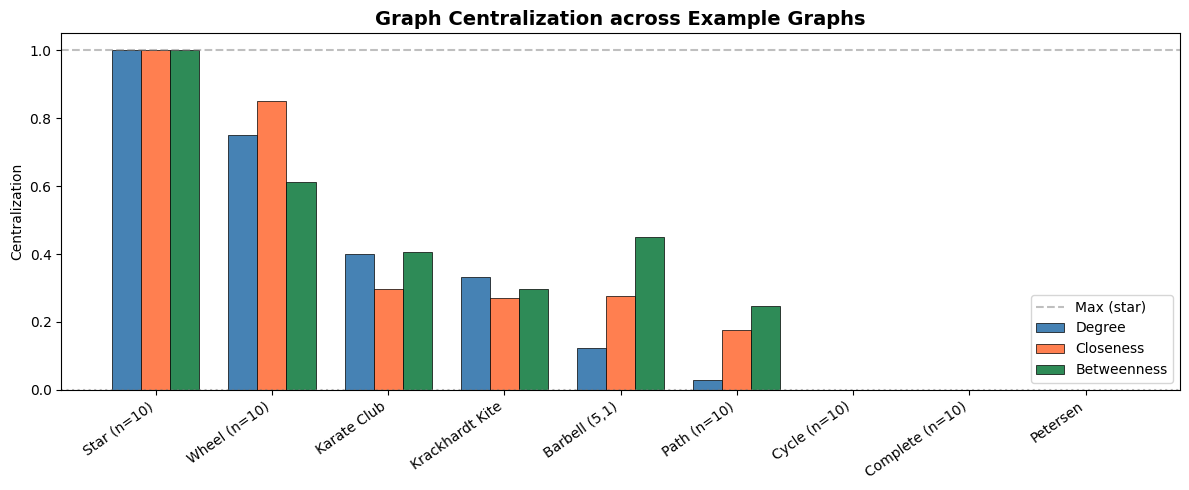

In [11]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))
df_plot = df_cz_pivot.drop(columns='Mean')
x = np.arange(len(df_plot))
width = 0.25
colours = ['steelblue', 'coral', 'seagreen']

for i, (col, colour) in enumerate(zip(df_plot.columns, colours)):
    ax.bar(x + i * width, df_plot[col], width, label=col, color=colour, edgecolor='k', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(df_plot.index, rotation=35, ha='right')
ax.set_ylabel('Centralization')
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5, label='Max (star)')
ax.axhline(0.0, color='grey', linestyle=':', alpha=0.5)
ax.legend()
ax.set_title('Graph Centralization across Example Graphs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Visual Comparison: Low vs High Centralization

Side-by-side graph drawings showing a star (max centralization) vs. a cycle (zero centralization) vs. the karate club (intermediate).

/tmp/ipykernel_31230/2023815684.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(norm(vals))


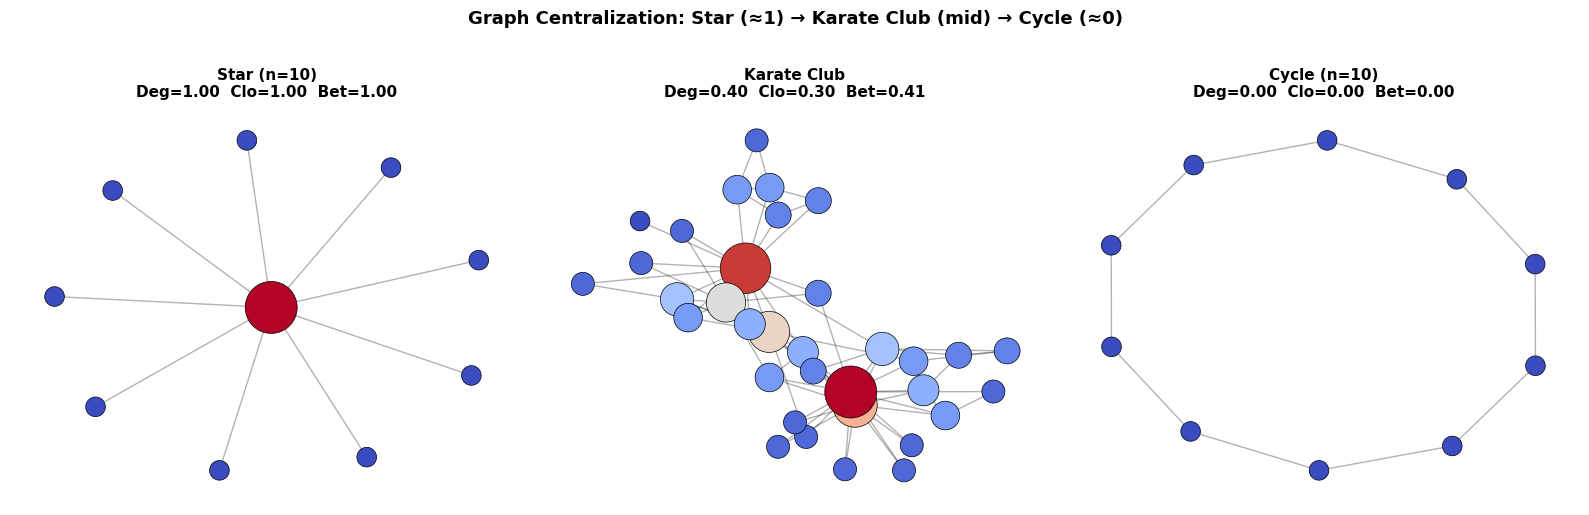

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

showcase = [
    ('Star (n=10)',    nx.star_graph(9)),
    ('Karate Club',   nx.karate_club_graph()),
    ('Cycle (n=10)',  nx.cycle_graph(10)),
]

for ax, (gname, G) in zip(axes, showcase):
    pos = nx.spring_layout(G, seed=42)
    deg = nx.degree_centrality(G)
    vals = np.array([deg[n] for n in G.nodes()])
    norm = Normalize(vmin=vals.min(), vmax=vals.max())
    colours = cm.get_cmap('coolwarm')(norm(vals))
    sizes = 200 + 1200 * norm(vals)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colours, node_size=sizes,
                           edgecolors='k', linewidths=0.5)

    cz_deg = graph_centralization(G, nx.degree_centrality)
    cz_bet = graph_centralization(G, nx.betweenness_centrality)
    cz_clo = graph_centralization(G, nx.closeness_centrality)
    ax.set_title(f'{gname}\nDeg={cz_deg:.2f}  Clo={cz_clo:.2f}  Bet={cz_bet:.2f}',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

fig.suptitle('Graph Centralization: Star (≈1) → Karate Club (mid) → Cycle (≈0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_31230/3419554070.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = cm.get_cmap('coolwarm')(norm(vals))


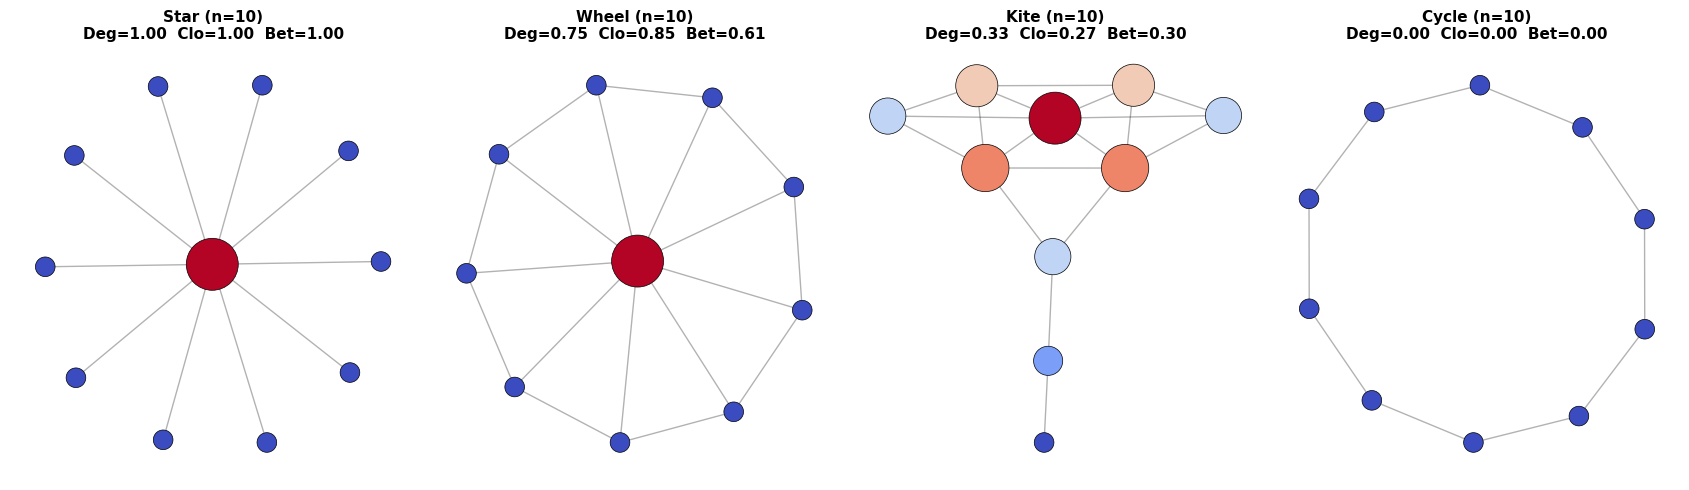

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

showcase = [
    ('Star (n=10)',    nx.star_graph(10)),
    ('Wheel (n=10)',  nx.wheel_graph(10)),
    ('Kite (n=10)',  nx.krackhardt_kite_graph()),
    ('Cycle (n=10)',  nx.cycle_graph(10)),
]

for ax, (gname, G) in zip(axes, showcase):
    pos = nx.spring_layout(G, seed=42)
    deg = nx.degree_centrality(G)
    vals = np.array([deg[n] for n in G.nodes()])
    norm = Normalize(vmin=vals.min(), vmax=vals.max())
    colours = cm.get_cmap('coolwarm')(norm(vals))
    sizes = 200 + 1200 * norm(vals)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colours, node_size=sizes,
                           edgecolors='k', linewidths=0.5)

    cz_deg = graph_centralization(G, nx.degree_centrality)
    cz_bet = graph_centralization(G, nx.betweenness_centrality)
    cz_clo = graph_centralization(G, nx.closeness_centrality)
    ax.set_title(f'{gname}\nDeg={cz_deg:.2f}  Clo={cz_clo:.2f}  Bet={cz_bet:.2f}',
                 fontsize=11, fontweight='bold')
    ax.axis('off')
    # plt.colorbar(cm.ScalarMappable(cmap='coolwarm', norm=norm), ax=ax, shrink=0.8)

# fig.suptitle('Graph Centralization: Star (≈1) → Cycle (≈0)',
#              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('examples_centralisation.png', dpi=300, transparent = True, bbox_inches='tight')